# Generar predicciones del modelo sin aplicar la heuristica.


In [4]:
import os
import sys
from pathlib import Path


ROOT = Path().resolve()
while ROOT.name != "pdf-key-extraction":
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / "src"))
os.chdir(ROOT)

from extract.key_value_extractor import KeyValueExtractor

extractor = KeyValueExtractor()

pdf_dir = ROOT / "evaluate" / "pdfs"

for pdf_path in sorted(pdf_dir.glob("*.pdf")):
    print(f"\n{'=' * 80}")
    print(f"PDF: {pdf_path.name}")
    print(f"{'=' * 80}")

    try:
        predict = extractor.predict(pdf_path)
        print(predict)
    except Exception as e:
        print(f"ERROR: {e}")


PDF: 1106202601139174848500120080200000487350004873513.pdf


c:\Users\itami\miniconda3\envs\pdf-key-extraction\Lib\site-packages\transformers\modeling_utils.py:1051: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(


{'form': [{'field': 'R.U.C.:', 'value': '1391748485001', 'value_type': 'FIELD_VALUE_ID', 'is_reliable': True, 'selected_by': 'heuristic', 'candidates': [{'value': '1391748485001', 'score': 1536.06}]}, {'field': 'No.', 'value': '008-020-000048735', 'value_type': 'FIELD_VALUE_ID', 'is_reliable': True, 'selected_by': 'heuristic', 'candidates': [{'value': '008-020-000048735', 'score': 1594.56}]}, {'field': 'NÚMERO DE AUTORIZACIÓN', 'value': '1106202601139174848500120080200000487350004873513', 'value_type': 'FIELD_VALUE_ID', 'is_reliable': True, 'selected_by': 'heuristic', 'candidates': [{'value': '1106202601139174848500120080200000487350004873513', 'score': 1319.5}]}, {'field': 'FECHA Y HORA DE AUTORIZACIÓN:', 'value': datetime.datetime(2026, 6, 11, 16, 51, 6), 'value_type': 'FIELD_VALUE_DATE', 'is_reliable': True, 'selected_by': 'heuristic', 'candidates': [{'value': datetime.datetime(2026, 6, 11, 16, 51, 6), 'score': 1531.05}]}, {'field': 'AMBIENTE:', 'value': 'PRODUCCIÓN', 'value_type': 

EVALUACIÓN DE DOCUMENTO 1106202601139174848500120080200000487350004873513.json
Campo #1:
  • Ground Truth -> text: 'R.U.C.:' | label: 'FIELD_KEY_ID'
  • Predicción   -> word: 'r.u.c.:' | label: 'FIELD_KEY_ID'
  • Evaluación   -> ✅ CORRECTO
-------------------------------------------------------------------------------------
EVALUACIÓN DE DOCUMENTO 1106202601139174848500120080200000487350004873513.json
Campo #2:
  • Ground Truth -> text: '1391748485001' | label: 'FIELD_VALUE_ID'
  • Predicción   -> word: '1391748485001' | label: 'FIELD_VALUE_ID'
  • Evaluación   -> ✅ CORRECTO
-------------------------------------------------------------------------------------
EVALUACIÓN DE DOCUMENTO 1706202601139174848500120080200000490960004909618.json
Campo #1:
  • Ground Truth -> text: 'R.U.C.:' | label: 'FIELD_KEY_ID'
  • Predicción   -> word: 'r.u.c.:' | label: 'FIELD_KEY_ID'
  • Evaluación   -> ✅ CORRECTO
-------------------------------------------------------------------------------------
EVALUA

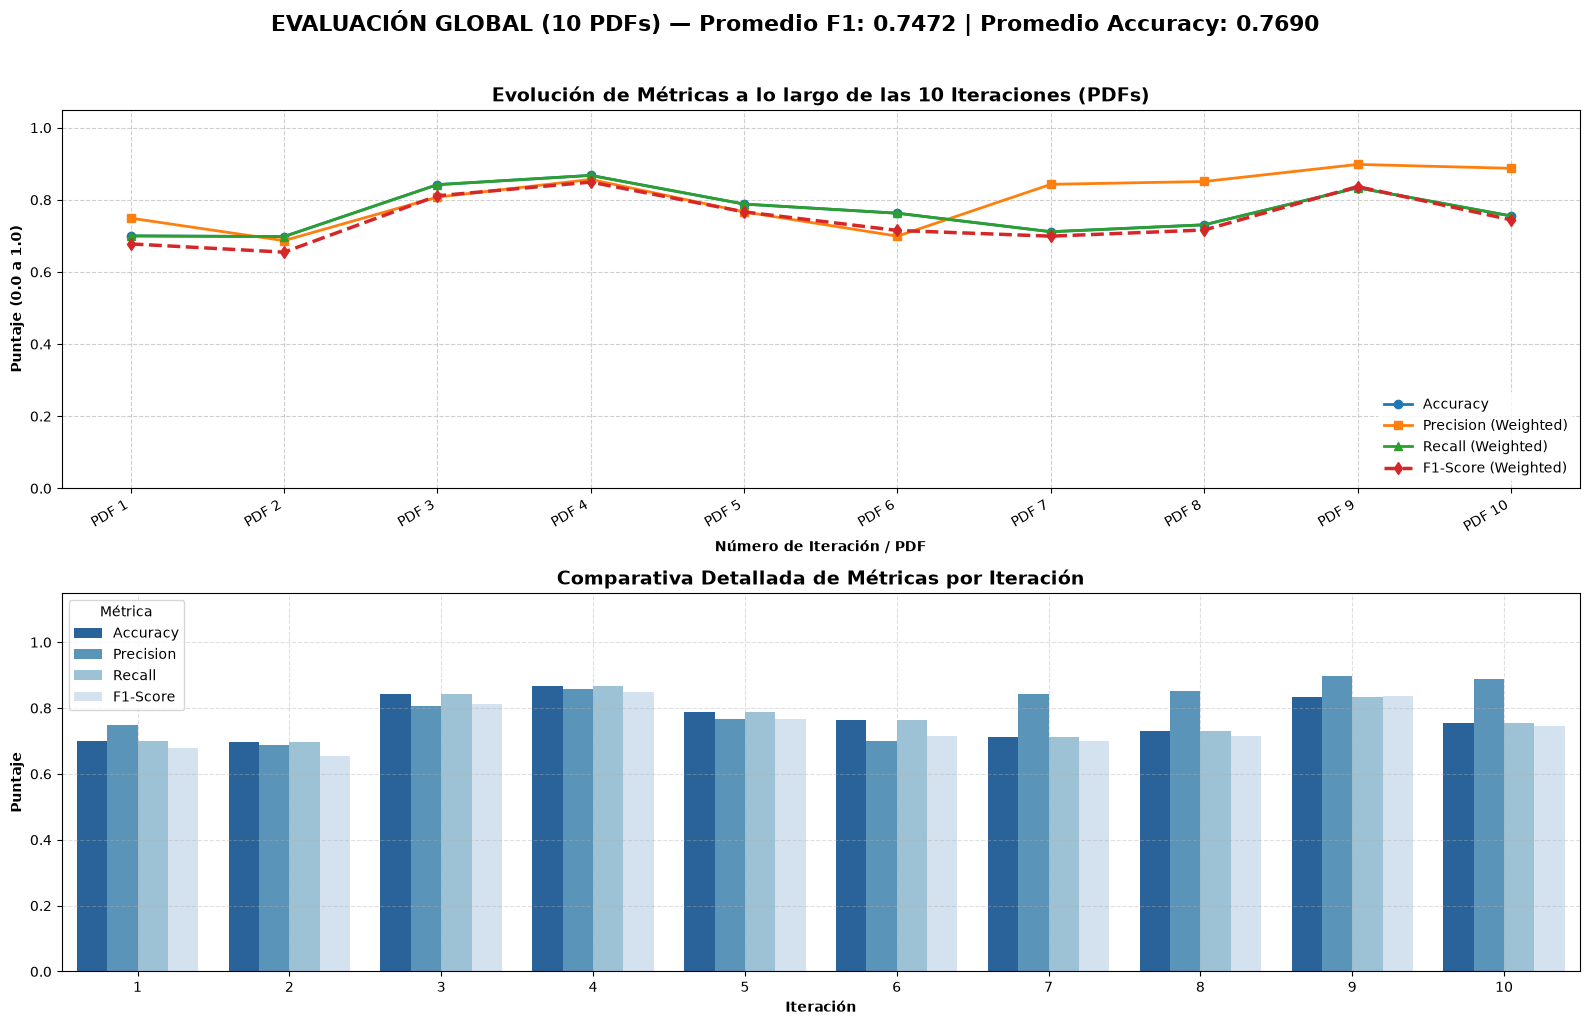


TABLA RESUMEN DE LAS 10 ITERACIONES:
 Iteración                                         Documento  Accuracy  Precision   Recall  F1-Score  Total_Campos
         1 1106202601139174848500120080200000487350004873513  0.700000   0.749236 0.700000  0.677825           170
         2 1706202601139174848500120080200000490960004909618  0.698113   0.686837 0.698113  0.654890           106
         3 1706202601139174848500120080200000491290004912919  0.842105   0.807618 0.842105  0.811123           114
         4 2206202601139175319500123020030003318020000308513  0.867769   0.856586 0.867769  0.849228           121
         5 2906202601099001751400121650060010377100000000012  0.788235   0.766560 0.788235  0.766599            85
         6 2908202601099000419600120372010001521100015211018  0.762821   0.699225 0.762821  0.715035           156
         7 2908202601099151772300120020010002687650026876519  0.711538   0.842997 0.711538  0.699255           104
         8 2908202601099151772300120020040

In [29]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, classification_report

# 1. Definición de Rutas
GT_DIR = ROOT / "evaluate" / "jsons"
PRED_DIR = ROOT / "predictions"

# 2. Obtener lista de archivos Ground Truth
gt_files = sorted(list(GT_DIR.glob("*.json")))

if not gt_files:
    raise FileNotFoundError(f"No se encontraron archivos JSON en {GT_DIR}")

def normalize_text(text):
    return " ".join(str(text).lower().split())

# Estructuras para almacenar los resultados de cada iteración
iteration_metrics = []

# 3. Bucle para procesar cada uno de los 10 archivos
for idx, gt_path in enumerate(gt_files, 1):
    filename = gt_path.name
    
    # Buscar el archivo de predicción correspondiente 
    pred_path = PRED_DIR / filename
    if not pred_path.exists():
        # Fallback por si la predicción tiene sufijo o formato estándar (ej: pred_documento_1.json)
        possible_preds = list(PRED_DIR.glob(f"*{gt_path.stem}*.json"))
        if possible_preds:
            pred_path = possible_preds[0]
        else:
            print(f"[ITERACIÓN {idx}] ⚠️ No se encontró predicción para {filename}. Omitiendo...")
            continue

    # A. Cargar Ground Truth
    with open(gt_path, "r", encoding="utf-8") as f:
        gt_data = json.load(f)
    gt_elements = gt_data if isinstance(gt_data, list) else gt_data.get("elements", [])

    # B. Cargar Predicción
    with open(pred_path, "r", encoding="utf-8") as f:
        pred_data = json.load(f)

    # C. Aplanar la predicción
    flat_predictions = []
    if isinstance(pred_data, list):
        for page_obj in pred_data:
            words = page_obj.get("words", [])
            labels = page_obj.get("labels", [])
            page_num = page_obj.get("page", None)

            for word, label in zip(words, labels):
                word_clean = normalize_text(word)
                flat_predictions.append({
                    "word": word_clean,
                    "label": label,
                    "page": page_num
                })

    # D. Alineación y Comparación
    y_true = []
    y_pred = []
    comparison_details = []

    for gt_item in gt_elements:
        gt_text = gt_item.get("text", "")
        gt_label = gt_item.get("label", "O")
        gt_page = gt_item.get("page", None)
        
        gt_text_norm = normalize_text(gt_text)
        matched_label = "O"

        for pred in flat_predictions:
            if gt_page is not None and pred["page"] is not None and gt_page != pred["page"]:
                continue
                
            if pred["word"] == gt_text_norm or (gt_text_norm and gt_text_norm in pred["word"]):
                matched_label = pred["label"]
                break

        y_true.append(gt_label)
        y_pred.append(matched_label)

   
    # E. Cálculo de métricas del documento actual
    if y_true:
        acc = accuracy_score(y_true, y_pred)
        prec, rec, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average="weighted", zero_division=0
        )
        
        iteration_metrics.append({
            "Iteración": idx,
            "Documento": gt_path.stem,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1-Score": f1,
            "Total_Campos": len(y_true)
        })

    for idx, gt_item in enumerate(gt_elements, 1):
        gt_text = gt_item.get("text", "")
        gt_label = gt_item.get("label", "O")
        gt_page = gt_item.get("page", None)
        
        gt_text_norm = normalize_text(gt_text)
        
        matched_label = "O"
        matched_word = None

        for pred in flat_predictions:
            if gt_page is not None and pred["page"] is not None and gt_page != pred["page"]:
                continue
                
            if pred["word"] == gt_text_norm or (gt_text_norm and gt_text_norm in pred["word"]):
                matched_label = pred["label"]
                matched_word = pred["word"]
                break

        y_true.append(gt_label)
        y_pred.append(matched_label)

        comparison_details.append({
            "gt_text": gt_text,
            "gt_label": gt_label,
            "pred_word": matched_word,
            "pred_label": matched_label,
            "correct": gt_label == matched_label
        })

    for i, detail in enumerate(comparison_details[:2], 1):
        print("=" * 85)
        print(f"EVALUACIÓN DE DOCUMENTO {filename}")
        print("=" * 85)

        print(f"Campo #{i}:")
        print(f"  • Ground Truth -> text: '{detail['gt_text']}' | label: '{detail['gt_label']}'")
        if detail["pred_word"] is not None:
            print(f"  • Predicción   -> word: '{detail['pred_word']}' | label: '{detail['pred_label']}'")
            print(f"  • Evaluación   -> {'✅ CORRECTO' if detail['correct'] else '❌ DISCREPANCIA (Label Incorrecto)'}")
        else:
            print(f"  • Predicción   -> [NO DETECTADO EN PREDICCIÓN] | label predicho asignado: 'O'")
            print(f"  • Evaluación   -> ❌ FALSO NEGATIVO")
        print("-" * 85)
        

# 4. Crear DataFrame con las métricas acumuladas
df_metrics = pd.DataFrame(iteration_metrics)

# 5. Generar Gráficas para las 10 Iteraciones
plt.figure(figsize=(16, 10))

# --- Gráfica 1: Líneas de Tendencia por Iteración ---
ax1 = plt.subplot(2, 1, 1)
x = df_metrics["Iteración"]

plt.plot(x, df_metrics["Accuracy"], marker='o', linewidth=2, label="Accuracy", color="#1f77b4")
plt.plot(x, df_metrics["Precision"], marker='s', linewidth=2, label="Precision (Weighted)", color="#ff7f0e")
plt.plot(x, df_metrics["Recall"], marker='^', linewidth=2, label="Recall (Weighted)", color="#2ca02c")
plt.plot(x, df_metrics["F1-Score"], marker='d', linewidth=2.5, linestyle="--", label="F1-Score (Weighted)", color="#d62728")

plt.title("Evolución de Métricas a lo largo de las 10 Iteraciones (PDFs)", fontsize=14, fontweight="bold")
plt.xlabel("Número de Iteración / PDF", fontweight="bold")
plt.ylabel("Puntaje (0.0 a 1.0)", fontweight="bold")
plt.xticks(x, [f"PDF {i}" for i, doc in zip(df_metrics["Iteración"], df_metrics["Documento"])], rotation=30, ha="right")
plt.ylim(0, 1.05)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="lower right", frameon=True, facecolor="white", edgecolor="none")

# --- Gráfica 2: Comparativa de Barras Agrupadas por PDF ---
ax2 = plt.subplot(2, 1, 2)
df_melted = df_metrics.melt(id_vars=["Iteración", "Documento"], 
                            value_vars=["Accuracy", "Precision", "Recall", "F1-Score"],
                            var_name="Métrica", value_name="Valor")

sns.barplot(data=df_melted, x="Iteración", y="Valor", hue="Métrica", palette="Blues_r", ax=ax2)
plt.title("Comparativa Detallada de Métricas por Iteración", fontsize=14, fontweight="bold")
plt.xlabel("Iteración", fontweight="bold")
plt.ylabel("Puntaje", fontweight="bold")
plt.ylim(0, 1.15)
plt.grid(True, linestyle="--", alpha=0.4)

# Agregar promedio global en el título del gráfico
mean_f1 = df_metrics["F1-Score"].mean()
mean_acc = df_metrics["Accuracy"].mean()
plt.suptitle(f"EVALUACIÓN GLOBAL (10 PDFs) — Promedio F1: {mean_f1:.4f} | Promedio Accuracy: {mean_acc:.4f}", 
             fontsize=16, fontweight="bold", y=1.02)

plt.tight_layout()
plt.show()

# 6. Tabla Resumen Consolidada
print("\n" + "=" * 90)
print("TABLA RESUMEN DE LAS 10 ITERACIONES:")
print("=" * 90)
print(df_metrics.to_string(index=False))

classes = sorted(list(set(y_true + y_pred)))

print("\n" + "=" * 85)
print("REPORTE DE CLASIFICACIÓN DETALLADO POR ETIQUETA:")
print("=" * 85)
print(classification_report(y_true, y_pred, target_names=classes, digits=4, zero_division=0))

PROCESANDO Y CONSOLIDADNDO 10 DOCUMENTOS (PDFs)
• PDF 01 [110620260113917484850012008020] -> Processados 170 campos | F1: 0.6778
• PDF 02 [170620260113917484850012008020] -> Processados 106 campos | F1: 0.6549
• PDF 03 [170620260113917484850012008020] -> Processados 114 campos | F1: 0.8111
• PDF 04 [220620260113917531950012302003] -> Processados 121 campos | F1: 0.8492
• PDF 05 [290620260109900175140012165006] -> Processados 85 campos | F1: 0.7666
• PDF 06 [290820260109900041960012037201] -> Processados 156 campos | F1: 0.7150
• PDF 07 [290820260109915177230012002001] -> Processados 104 campos | F1: 0.6993
• PDF 08 [290820260109915177230012002004] -> Processados 104 campos | F1: 0.7164
• PDF 09 [290820260109915177230012002006] -> Processados 96 campos | F1: 0.8368
• PDF 10 [290820260117909855040012025024] -> Processados 94 campos | F1: 0.7446

REPORTE DE CLASIFICACIÓN DETALLADO CONSOLIDADO (10 PDFs - 1150 CAMPOS TOTALES)
                                precision    recall  f1-score   s

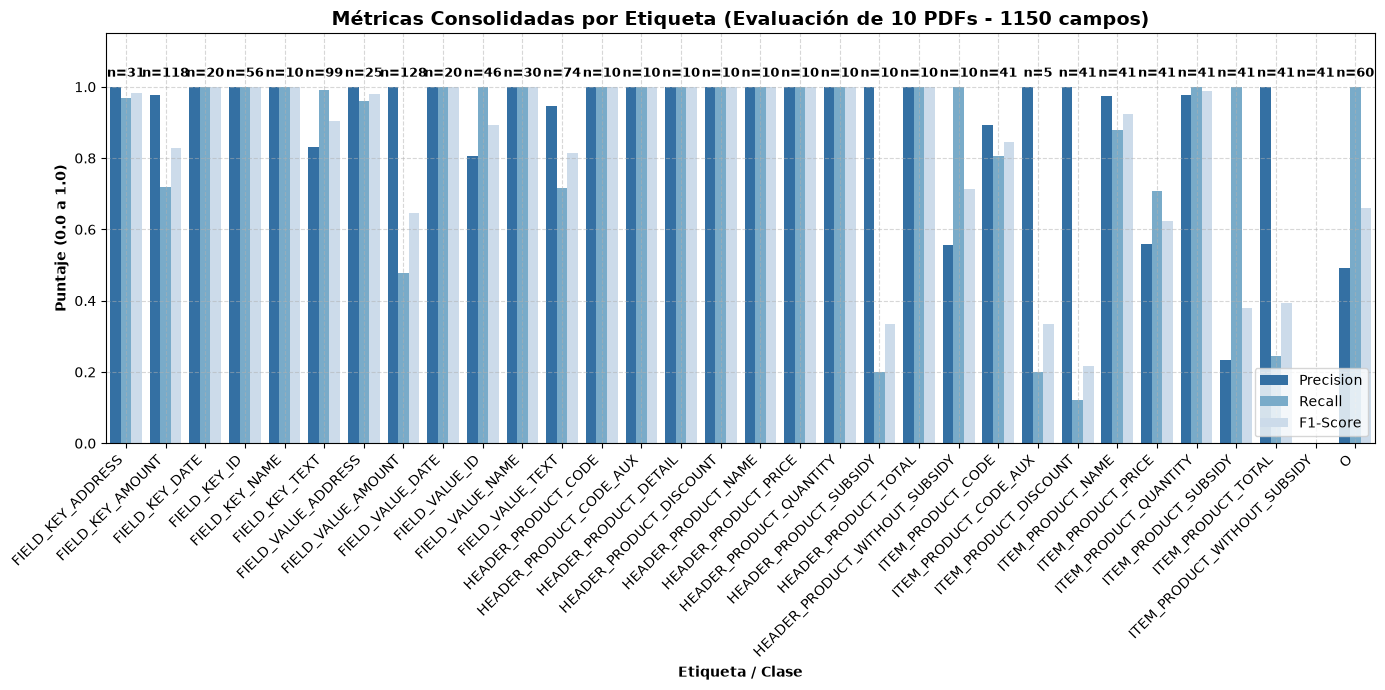

In [32]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import classification_report, precision_recall_fscore_support, accuracy_score

# 1. Definición de Rutas
GT_DIR = ROOT / "evaluate" / "jsons"
PRED_DIR = ROOT / "predictions"

gt_files = sorted(list(GT_DIR.glob("*.json")))

if not gt_files:
    raise FileNotFoundError(f"No se encontraron archivos JSON en {GT_DIR}")

def normalize_text(text):
    return " ".join(str(text).lower().split())

# Vectores globales para consolidar los 10 PDFs
y_true_global = []
y_pred_global = []

# Métrica por documento individual para trazabilidad
doc_summaries = []

print("=" * 90)
print(f"PROCESANDO Y CONSOLIDADNDO {len(gt_files)} DOCUMENTOS (PDFs)")
print("=" * 90)

# 2. Iterar sobre cada uno de los PDFs y acumular en los vectores globales
for idx, gt_path in enumerate(gt_files, 1):
    filename = gt_path.name
    
    # Buscar el archivo de predicción correspondiente
    pred_path = PRED_DIR / filename
    if not pred_path.exists():
        possible_preds = list(PRED_DIR.glob(f"*{gt_path.stem}*.json"))
        if possible_preds:
            pred_path = possible_preds[0]
        else:
            print(f"[PDF {idx:02d}] ⚠️ No se encontró predicción para {filename}. Omitiendo...")
            continue

    # A. Cargar Ground Truth
    with open(gt_path, "r", encoding="utf-8") as f:
        gt_data = json.load(f)
    gt_elements = gt_data if isinstance(gt_data, list) else gt_data.get("elements", [])

    # B. Cargar Predicción
    with open(pred_path, "r", encoding="utf-8") as f:
        pred_data = json.load(f)

    # C. Aplanar la predicción de este PDF
    flat_predictions = []
    if isinstance(pred_data, list):
        for page_obj in pred_data:
            words = page_obj.get("words", [])
            labels = page_obj.get("labels", [])
            page_num = page_obj.get("page", None)

            for word, label in zip(words, labels):
                word_clean = normalize_text(word)
                flat_predictions.append({
                    "word": word_clean,
                    "label": label,
                    "page": page_num
                })

    # D. Alineación y Comparación a nivel de campo
    y_true_doc = []
    y_pred_doc = []

    for gt_item in gt_elements:
        gt_text = gt_item.get("text", "")
        gt_label = gt_item.get("label", "O")
        gt_page = gt_item.get("page", None)
        
        gt_text_norm = normalize_text(gt_text)
        matched_label = "O"

        for pred in flat_predictions:
            if gt_page is not None and pred["page"] is not None and gt_page != pred["page"]:
                continue
                
            if pred["word"] == gt_text_norm or (gt_text_norm and gt_text_norm in pred["word"]):
                matched_label = pred["label"]
                break

        y_true_doc.append(gt_label)
        y_pred_doc.append(matched_label)

    # E. Acumular en los vectores globales
    y_true_global.extend(y_true_doc)
    y_pred_global.extend(y_pred_doc)
    
    doc_f1 = precision_recall_fscore_support(y_true_doc, y_pred_doc, average="weighted", zero_division=0)[2]
    doc_summaries.append({"PDF": gt_path.stem, "Campos": len(y_true_doc), "F1_Score": doc_f1})
    print(f"• PDF {idx:02d} [{gt_path.stem[:30]:<30}] -> Processados {len(y_true_doc)} campos | F1: {doc_f1:.4f}")

# 3. Reporte de Clasificación Consolidado (Las 10 iteraciones unificadas)
classes = sorted(list(set(y_true_global + y_pred_global)))

print("\n" + "=" * 90)
print(f"REPORTE DE CLASIFICACIÓN DETALLADO CONSOLIDADO ({len(gt_files)} PDFs - {len(y_true_global)} CAMPOS TOTALES)")
print("=" * 90)
print(classification_report(y_true_global, y_pred_global, target_names=classes, digits=4, zero_division=0))

# 4. Métricas Resumidas Globales
acc_global = accuracy_score(y_true_global, y_pred_global)
p_glob, r_glob, f1_glob, _ = precision_recall_fscore_support(
    y_true_global, y_pred_global, average="weighted", zero_division=0
)

print("=" * 90)
print("RESUMEN DE MÉTRICAS GLOBALES CONSOLIDADAS:")
print(f"  • Total de Campos Evaluados : {len(y_true_global)}")
print(f"  • Accuracy Global           : {acc_global:.4f}")
print(f"  • Precision (Weighted)      : {p_glob:.4f}")
print(f"  • Recall (Weighted)         : {r_glob:.4f}")
print(f"  • F1-Score (Weighted)       : {f1_glob:.4f}")
print("=" * 90)

# 5. Gráfica de Métricas por Etiqueta (Consolidado)
p_cls, r_cls, f1_cls, support_cls = precision_recall_fscore_support(
    y_true_global, y_pred_global, labels=classes, zero_division=0
)

df_cls = pd.DataFrame({
    "Etiqueta": classes,
    "Precision": p_cls,
    "Recall": r_cls,
    "F1-Score": f1_cls,
    "Soporte": support_cls
})

plt.figure(figsize=(14, 7))
df_melted = df_cls.melt(id_vars=["Etiqueta", "Soporte"], value_vars=["Precision", "Recall", "F1-Score"],
                        var_name="Métrica", value_name="Valor")

ax = sns.barplot(data=df_melted, x="Etiqueta", y="Valor", hue="Métrica", palette="Blues_r")

# Añadir el número de soporte (instancias) arriba de las barras de cada clase
for idx_cls, row in df_cls.iterrows():
    ax.text(idx_cls, 1.02, f"n={row['Soporte']}", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title(f"Métricas Consolidadas por Etiqueta (Evaluación de 10 PDFs - {len(y_true_global)} campos)", 
          fontsize=14, fontweight="bold")
plt.xlabel("Etiqueta / Clase", fontweight="bold")
plt.ylabel("Puntaje (0.0 a 1.0)", fontweight="bold")
plt.ylim(0, 1.15)
plt.xticks(rotation=45, ha="right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()